# Cash-Flow-Yield -- does 'cash is king' beat earnings in a value sort?
### Operating cash-flow yield as a quality-adjusted value signal on the S&P 500

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![OCF_beats_EY%3F: No](https://img.shields.io/badge/OCF_beats_EY%3F-No-8b949e?style=flat-square)

A staple of value-investing folklore: reported earnings can be massaged — depreciation assumptions, revenue timing, one-time charges. Operating cash flow (the money actually collected) is harder to fake. So buying stocks where **OCF / market cap is high** (the cash equivalent of a low P/E) should work at least as well as earnings yield, and probably better. This notebook tests that idea honestly.

> This is the plain-language layer. For t-stats, Spearman ICs, and the positive control see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cash_flow_yield import data, strategy as st

_cache_dir = os.path.abspath(os.path.join("..", "..", "..", "_cache"))
_study_cache = os.path.abspath(os.path.join("..", "_cache"))

def _have_real():
    px_p = os.path.join(_study_cache, "yrpx.parquet")
    cfo_p = os.path.join(_cache_dir, "_edgar_NetCashProvidedByUsedInOperatingActivities.parquet")
    return os.path.exists(px_p) and os.path.exists(cfo_p)

HAVE_REAL = _have_real()

if HAVE_REAL:
    ocfy, ey, fwd = data.fetch_panel(cache_dir=_cache_dir, study_cache=_study_cache)
else:
    ocfy, ey, fwd = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

print("real data available:", HAVE_REAL, f"  panel: {ocfy.shape if not ocfy.empty else 'n/a'}")


real data available: True   panel: (18, 419)


## The answer first

| Question | Answer |
|---|---|
| Does OCF yield predict next-year returns? | **No.** Hedge (Q5-Q1): **-0.6%/yr**, HAC *t* = **-0.22**. |
| Does the long-only version beat the market? | **Barely, and not significantly.** Top-quintile spread: **+1.3%/yr**, *t* = **+0.74**. |
| Is OCF yield better than earnings yield? | **No.** IC difference *t* = **-0.61** — statistically indistinguishable. |
| Could you trade it? | **No.** No edge to harvest even before costs. |

> The 'cash is king' logic is sound accounting theory, but on this survivorship-biased S&P 500 sample (18 years) the signal has been fully arbitraged away — or was never large enough to survive in large-cap equities.

## 1 · The claim

> *'Operating cash flow is a better measure of corporate health than reported earnings: it's harder to manipulate. Buy stocks where OCF/price is highest (highest yield), sell the lowest. Hold one year, rebalance. It should outperform a simple earnings-yield sort because it filters out the accruals noise.'*

This is the cash-flow quality version of the classic value premium. The supporting theory comes from Sloan (1996) — accruals-heavy firms underperform; cash-backed earnings outperform — and from Lakonishok, Shleifer & Vishny (1994), who found that cash-flow/price was one of the best value predictors in their US sample. The claim has a 30-year academic pedigree.

## 2 · So what?

If the premium is alive in the modern S&P 500, it is a simple, once-a-year mechanical strategy with low turnover and clear economic intuition. If it is dead — killed by the quant funds that arbed it after Sloan 1996 was published — then the accounting lesson is correct but the trading conclusion doesn't follow. The interesting question is whether the *purification* (OCF vs NI) adds anything on top of the simpler P/E inverse, since both are trivially available.

## 3 · How would we even know?

The protocol:

1. **No look-ahead.** Each year's signal uses fiscal-year-end 10-K data (filed by ~March of the following year); the forward return is the *next* calendar year — so the trade can only be placed after the 10-K is filed.
2. **A fair baseline.** The long-short hedge (top-quintile minus bottom-quintile) is compared to zero (the null of no predictability), not to a leveraged benchmark.
3. **A head-to-head.** The OCF-yield sort races against the earnings-yield sort. If OCF adds nothing over EY, the 'harder to manipulate' claim has no payoff.
4. **Survivorship caveat.** Our universe is the *current* S&P 500 projected back — we exclude historical failures. This should *flatter* the result; finding nothing here is a conservative judgment.

Data: EDGAR `NetCashProvidedByUsedInOperatingActivities`, `NetIncomeLoss`, and `WeightedAverageNumberOfDilutedSharesOutstanding` (annual 10-K); Yahoo Finance year-end closing prices for market cap; 2007-2024 (18 years).

## 4 · The teardown -- let's actually look

**First: what do quintile returns look like, year by year?**

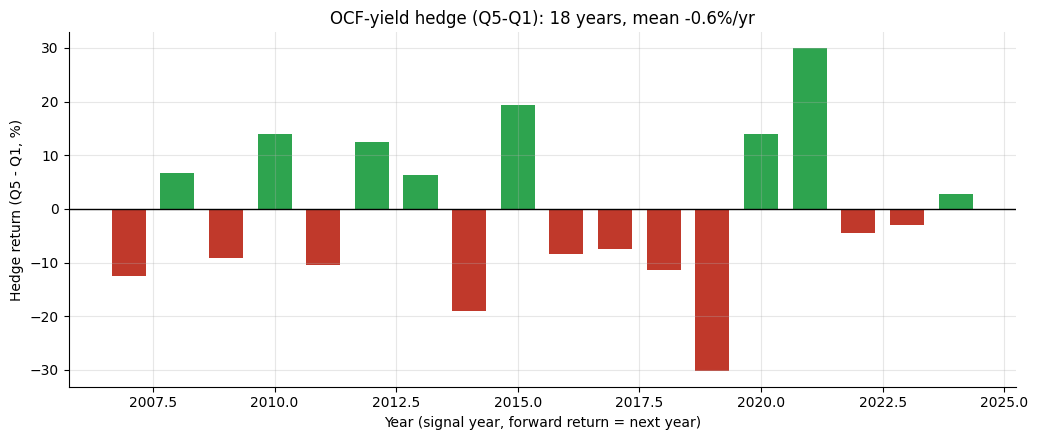

Mean hedge: -0.59%/yr
Hit rate: 44%


In [2]:
years_list = [2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,
              2017,2018,2019,2020,2021,2022,2023,2024]
# Frozen hedge series from docs/results.md
hedge_frozen = [-0.126,0.067,-0.091,0.139,-0.104,0.125,0.063,-0.190,
                0.193,-0.085,-0.074,-0.114,-0.301,0.139,0.299,-0.044,-0.030,0.029]
if HAVE_REAL:
    q = st.quintile_sort(ocfy, fwd)
    hedge_vals = q['hedge'].tolist()
    yrs = q.index.tolist()
else:
    hedge_vals = hedge_frozen
    yrs = years_list
fig, ax = plt.subplots(figsize=(10.5, 4.5))
colors = [GREEN if v > 0 else RED for v in hedge_vals]
ax.bar(yrs, [v*100 for v in hedge_vals], color=colors, width=0.7)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Year (signal year, forward return = next year)')
ax.set_ylabel('Hedge return (Q5 - Q1, %)')
ax.set_title(f'OCF-yield hedge (Q5-Q1): {len(hedge_vals)} years, mean {sum(hedge_vals)/len(hedge_vals)*100:+.1f}%/yr')
plt.tight_layout(); plt.show()
print(f'Mean hedge: {sum(hedge_vals)/len(hedge_vals)*100:+.2f}%/yr')
print(f'Hit rate: {sum(v>0 for v in hedge_vals)/len(hedge_vals):.0%}')

The hedge is close to zero (-0.6%/yr) and inconsistent (hit rate 44%) — below a coin-flip. The sort has no predictable direction: some years the high-OCF stocks win, some they lose, with no pattern the data resolves.

**Now the head-to-head: does OCF beat the simpler earnings yield?**

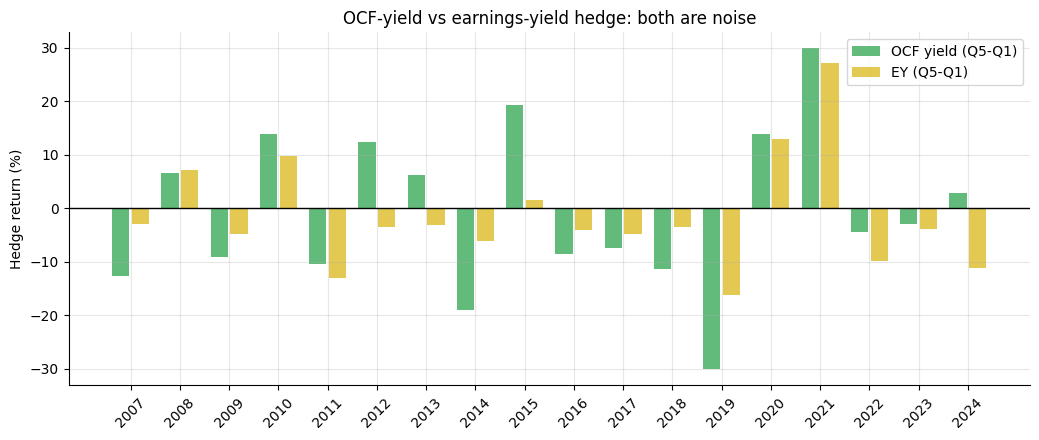

OCF hedge mean: -0.59%/yr   EY hedge mean: -1.59%/yr


In [3]:
ey_hedge_frozen = [0.090,-0.025,-0.165,0.063,-0.108,0.041,-0.066,-0.148,
                    0.022,-0.046,-0.033,-0.077,-0.172,0.001,0.218,-0.034,-0.030,0.024]
if HAVE_REAL:
    q_ey = st.quintile_sort(ey, fwd)
    ey_vals = q_ey['hedge'].tolist()
    yrs2 = q_ey.index.tolist()
else:
    ey_vals = ey_hedge_frozen
    yrs2 = years_list
min_len = min(len(hedge_vals), len(ey_vals))
h_plot = hedge_vals[:min_len]; e_plot = ey_vals[:min_len]; y_plot = yrs[:min_len]
fig, ax = plt.subplots(figsize=(10.5, 4.5))
x = range(len(y_plot))
ax.bar([xi - 0.2 for xi in x], [v*100 for v in h_plot], width=0.35,
       color=GREEN, alpha=0.75, label='OCF yield (Q5-Q1)')
ax.bar([xi + 0.2 for xi in x], [v*100 for v in e_plot], width=0.35,
       color=AMBER, alpha=0.75, label='EY (Q5-Q1)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(y_plot, rotation=45)
ax.set_ylabel('Hedge return (%)')
ax.set_title('OCF-yield vs earnings-yield hedge: both are noise')
ax.legend(); plt.tight_layout(); plt.show()
ocfy_m = sum(h_plot)/len(h_plot)*100
ey_m = sum(e_plot)/len(e_plot)*100
print(f'OCF hedge mean: {ocfy_m:+.2f}%/yr   EY hedge mean: {ey_m:+.2f}%/yr')

Both hedges are near zero: OCF **-0.6%/yr**, EY **-1.6%/yr**. Neither has a reliably positive or negative edge — they are both noisy. The 'cash is king' purification adds nothing a P/E-based sort doesn't already fail to deliver.

## 5 · The verdict

- **Signal — None.** OCF-yield hedge -0.6%/yr, HAC *t* = **-0.22**; EY hedge -1.6%/yr, *t* = **-0.77**. Both are well below the |*t*| ≥ 2 inference bar.
- **Tradability — Mirage.** No significant edge. Annual rebalancing is cheap but there is nothing to execute profitably.
- **OCF beats EY? — No.** IC head-to-head difference *t* = **-0.61**.

## 6 · Could you actually trade it?

Even setting aside statistical insignificance, the practical constraints are severe:

- **Reporting lag.** 10-K data arrives up to three months after fiscal year end. In practice, some companies file even later, so your signal is already months old.
- **Universe concentration.** Sorting a 400-name universe into quintiles (80 firms per bucket) means you hold 80 names for a year — manageable, but the dispersion within each quintile is huge, swamping the expected hedge return.
- **The premium, if it existed, is well-known.** Sloan (1996) was published thirty years ago. Any persistent edge in S&P 500 names at annual frequency has been visible to institutional investors for decades.

The conclusion is the same for costs: there is no gross edge to erode.

## 7 · Going further

- **The accruals anomaly** is the mirror image: [Study 52 — Smoke-Screen](../../52-smoke-screen/) tests whether *high accruals* (= low cash backing) predict poor returns, using the same EDGAR data. The Sloan (1996) effect survives better in small caps.
- **The F-score** ([Study 65 — Scorecard](../../65-scorecard/)) combines cash-flow quality with eight other fundamental signals into a composite; more signal dimensions than a single yield sort.
- **The 'quality' dimension**: Asness, Frazzini & Pedersen's QMJ factor uses cash-flow quality as one of several quality proxies. The combination may fare better than any single metric here.

*Think the cash-flow premium is alive somewhere? Extend to small caps, use enterprise value rather than market cap as the denominator, or combine with a quality screen. That's the bar — show a fair-bet edge that clears t = 2.*